# Day 18 - SQL Window Function Customer Order Analysis

윈도우 함수를 이용해 고객별 주문 순서, 이전 주문일, 다음 주문일과 재주문 간격을 분석한다.

## 분석 목적

주문 상세 행을 유지하면서 고객별 주문 흐름을 확인한다.

- 각 주문이 고객의 몇 번째 주문인지 계산한다.
- 이전 주문 후 며칠 만에 다시 주문했는지 계산한다.
- 다음 주문일이 존재하는지 확인한다.
- 고객별 전체 주문 횟수와 주문 순위를 비교한다.

## 분석 질문

1. 각 주문은 고객의 몇 번째 주문인가?
2. 각 주문의 이전 주문일과 다음 주문일은 언제인가?
3. 이전 주문 후 현재 주문까지 며칠이 걸렸는가?
4. 고객별 전체 주문 수는 몇 건인가?
5. 주문 횟수가 많은 고객은 누구인가?

In [25]:
# 라이브러리 불러오기
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# 프로젝트 경로 설정
project_root = Path.cwd().parent
study_root = project_root.parent.parent

db_path = study_root / "SQL" / "database" / "retail_lab.db"
output_dir = project_root / "outputs"

output_dir.mkdir(parents=True, exist_ok=True)

print("프로젝트 경로:", project_root)
print("데이터베이스 경로:", db_path)
print("출력 경로:", output_dir)

프로젝트 경로: d:\Study\Projects\00_foundation_review
데이터베이스 경로: d:\Study\SQL\database\retail_lab.db
출력 경로: d:\Study\Projects\00_foundation_review\outputs


In [27]:
# DB 존재 여부 확인
print("DB 존재 여부:", db_path.exists())

DB 존재 여부: True


In [28]:
# 데이터베이스 연결
conn = sqlite3.connect(db_path)

print("데이터베이스 연결 완료")


데이터베이스 연결 완료


In [29]:
# 주문 순서 분석 SQL 작성
query = """
SELECT
    order_sequence.customer_id,
    order_sequence.customer_name,
    order_sequence.region,
    order_sequence.grade,
    order_sequence.order_id,
    order_sequence.order_date,
    order_sequence.status,
    order_sequence.order_sequence,
    order_sequence.customer_total_orders,
    order_sequence.previous_order_date,
    CAST(
        julianday(order_sequence.order_date)
        - julianday(order_sequence.previous_order_date)
        AS INTEGER
    ) AS days_since_previous_order,
    order_sequence.next_order_date,
    CASE
        WHEN order_sequence.order_sequence = 1 THEN 1
        ELSE 0
    END AS is_first_order
FROM (
    SELECT
        c.customer_id,
        c.customer_name,
        c.region,
        c.grade,
        o.order_id,
        o.order_date,
        o.status,
        ROW_NUMBER() OVER (
            PARTITION BY o.customer_id
            ORDER BY o.order_date, o.order_id
        ) AS order_sequence,
        COUNT(*) OVER (
            PARTITION BY o.customer_id
        ) AS customer_total_orders,
        LAG(o.order_date) OVER (
            PARTITION BY o.customer_id
            ORDER BY o.order_date, o.order_id
        ) AS previous_order_date,
        LEAD(o.order_date) OVER (
            PARTITION BY o.customer_id
            ORDER BY o.order_date, o.order_id
        ) AS next_order_date
    FROM orders AS o
    INNER JOIN customers AS c
        ON o.customer_id = c.customer_id
) AS order_sequence
ORDER BY
    order_sequence.customer_id,
    order_sequence.order_sequence
"""

In [30]:
# SQL 실행
df = pd.read_sql(query, conn)

print(df.head())

   customer_id customer_name region  grade  order_id  order_date     status  \
0            1           Kim  Seoul    VIP       101  2026-07-20       paid   
1            1           Kim  Seoul    VIP       103  2026-07-22       paid   
2            2           Lee  Busan  BASIC       102  2026-07-21       paid   
3            3          Park  Seoul   GOLD       104  2026-07-23  cancelled   

   order_sequence  customer_total_orders previous_order_date  \
0               1                      2                 NaN   
1               2                      2          2026-07-20   
2               1                      1                 NaN   
3               1                      1                 NaN   

   days_since_previous_order next_order_date  is_first_order  
0                        NaN      2026-07-22               1  
1                        2.0             NaN               0  
2                        NaN             NaN               1  
3                        NaN   

In [31]:
# DataFrame 크기 확인
print("행과 열 개수:", df.shape)

행과 열 개수: (4, 13)


In [32]:
# 자료형 확인
print(df.dtypes)

customer_id                    int64
customer_name                    str
region                           str
grade                            str
order_id                       int64
order_date                       str
status                           str
order_sequence                 int64
customer_total_orders          int64
previous_order_date              str
days_since_previous_order    float64
next_order_date                  str
is_first_order                 int64
dtype: object


In [33]:
# 결측치 확인
print(df.isna().sum())

customer_id                  0
customer_name                0
region                       0
grade                        0
order_id                     0
order_date                   0
status                       0
order_sequence               0
customer_total_orders        0
previous_order_date          3
days_since_previous_order    3
next_order_date              3
is_first_order               0
dtype: int64


In [34]:
# 날짜 자료형 변환
df["order_date"] = pd.to_datetime(df["order_date"])
df["previous_order_date"] = pd.to_datetime(df["previous_order_date"])
df["next_order_date"] = pd.to_datetime(df["next_order_date"])

print(df.dtypes)

customer_id                           int64
customer_name                           str
region                                  str
grade                                   str
order_id                              int64
order_date                   datetime64[us]
status                                  str
order_sequence                        int64
customer_total_orders                 int64
previous_order_date          datetime64[us]
days_since_previous_order           float64
next_order_date              datetime64[us]
is_first_order                        int64
dtype: object


In [35]:
# 주문 ID 중복 확인
duplicate_order_count = df["order_id"].duplicated().sum()

print("중복 주문 ID 수:", duplicate_order_count)

중복 주문 ID 수: 0


In [36]:
# 첫 주문 확인
first_orders = df[df["is_first_order"] == 1]

print(first_orders)

   customer_id customer_name region  grade  order_id order_date     status  \
0            1           Kim  Seoul    VIP       101 2026-07-20       paid   
2            2           Lee  Busan  BASIC       102 2026-07-21       paid   
3            3          Park  Seoul   GOLD       104 2026-07-23  cancelled   

   order_sequence  customer_total_orders previous_order_date  \
0               1                      2                 NaT   
2               1                      1                 NaT   
3               1                      1                 NaT   

   days_since_previous_order next_order_date  is_first_order  
0                        NaN      2026-07-22               1  
2                        NaN             NaT               1  
3                        NaN             NaT               1  


In [37]:
# 재주문 확인
repeat_orders = df[df["order_sequence"] >= 2]

print(repeat_orders)

   customer_id customer_name region grade  order_id order_date status  \
1            1           Kim  Seoul   VIP       103 2026-07-22   paid   

   order_sequence  customer_total_orders previous_order_date  \
1               2                      2          2026-07-20   

   days_since_previous_order next_order_date  is_first_order  
1                        2.0             NaT               0  


In [38]:
# 재주문까지 30일 이상 걸린 주문
long_interval_orders = df[
    df["days_since_previous_order"] >= 30
]

print(long_interval_orders)

Empty DataFrame
Columns: [customer_id, customer_name, region, grade, order_id, order_date, status, order_sequence, customer_total_orders, previous_order_date, days_since_previous_order, next_order_date, is_first_order]
Index: []


In [39]:
# 고객 주문 순위 SQL 작성
rank_query = """
SELECT
    customer_id,
    customer_name,
    region,
    grade,
    order_count,
    RANK() OVER (
        ORDER BY order_count DESC
    ) AS order_rank,
    DENSE_RANK() OVER (
        ORDER BY order_count DESC
    ) AS dense_order_rank
FROM (
    SELECT
        c.customer_id,
        c.customer_name,
        c.region,
        c.grade,
        COUNT(o.order_id) AS order_count
    FROM customers AS c
    LEFT JOIN orders AS o
        ON c.customer_id = o.customer_id
    GROUP BY
        c.customer_id,
        c.customer_name,
        c.region,
        c.grade
) AS customer_orders
ORDER BY order_rank, customer_id
"""

In [40]:
# 고객 주문 순위 불러오기
rank_df = pd.read_sql(rank_query, conn)

print(rank_df)

   customer_id customer_name   region  grade  order_count  order_rank  \
0            1           Kim    Seoul    VIP            2           1   
1            2           Lee    Busan  BASIC            1           2   
2            3          Park    Seoul   GOLD            1           2   
3            4          Choi  Incheon  BASIC            0           4   

   dense_order_rank  
0                 1  
1                 2  
2                 2  
3                 3  


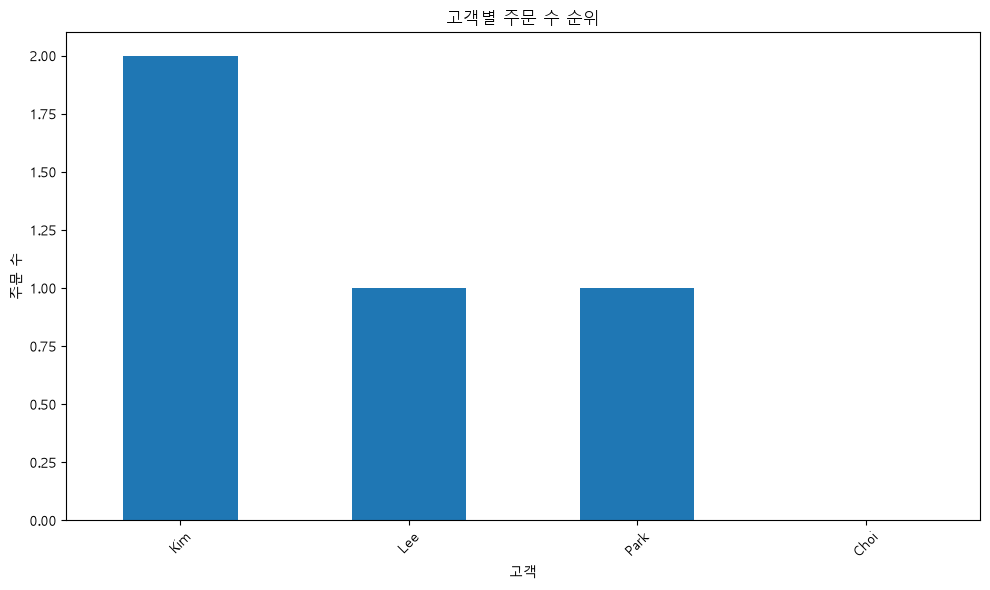

그래프 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_rank.png


In [41]:
# 고객 주문 수 그래프
rank_df.plot.bar(
    x="customer_name",
    y="order_count",
    figsize=(10, 6),
    legend=False
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.title("고객별 주문 수 순위")
plt.xlabel("고객")
plt.ylabel("주문 수")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = output_dir / "customer_order_rank.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("그래프 저장 경로:", figure_path)

In [42]:
# CSV 저장
output_path = output_dir / "customer_order_window_analysis.csv"

df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("CSV 저장 경로:", output_path)

CSV 저장 경로: d:\Study\Projects\00_foundation_review\outputs\customer_order_window_analysis.csv


In [43]:
# 저장 결과 확인
saved_df = pd.read_csv(output_path)

print(saved_df.head())
print("저장된 데이터 크기:", saved_df.shape)
print("CSV 존재 여부:", output_path.exists())
print("PNG 존재 여부:", figure_path.exists())

   customer_id customer_name region  grade  order_id  order_date     status  \
0            1           Kim  Seoul    VIP       101  2026-07-20       paid   
1            1           Kim  Seoul    VIP       103  2026-07-22       paid   
2            2           Lee  Busan  BASIC       102  2026-07-21       paid   
3            3          Park  Seoul   GOLD       104  2026-07-23  cancelled   

   order_sequence  customer_total_orders previous_order_date  \
0               1                      2                 NaN   
1               2                      2          2026-07-20   
2               1                      1                 NaN   
3               1                      1                 NaN   

   days_since_previous_order next_order_date  is_first_order  
0                        NaN      2026-07-22               1  
1                        2.0             NaN               0  
2                        NaN             NaN               1  
3                        NaN   

In [44]:
# 데이터베이스 연결 종료
conn.close()

print("데이터베이스 연결 종료")

데이터베이스 연결 종료


## 결과 해석

- 전체 주문은 4건이며, 각 주문에 고객별 주문 순서를 부여했다.
- 주문 이력이 있는 고객 중 재주문이 발생한 고객은 1명으로 확인됐다.
- 재주문까지 30일 이상 걸린 주문은 0건이었다.
- 고객별 주문 순서를 통해 첫 주문과 재주문을 구분할 수 있었다.
- 이전 주문 후 경과일이 짧은 고객은 상대적으로 반복 주문 활동이 높은 고객으로 볼 수 있다.
- 고객 주문 순위는 주문 빈도를 비교하는 기준이며, 매출 기여도 순위와는 다를 수 있다.

## 분석 한계

1. 현재 orders 테이블에는 상품 ID, 수량과 매출액이 없다.
2. 주문 횟수와 주문 간격은 분석할 수 있지만 고객별 매출 기여도는 판단할 수 없다.
3. 주문 상태를 제외하지 않았으므로 취소 주문이 주문 순서에 포함될 수 있다.
4. 고객 가입일이 없어 가입 후 첫 주문까지 걸린 기간은 계산할 수 없다.
5. 데이터의 마지막 주문일 이후 활동은 관측할 수 없으므로 다음 주문일이 NULL인 고객을 실제 이탈 고객으로 판단할 수 없다.
6. 고객 수와 주문 수가 적으면 주문 간격 평균이나 고객 순위가 일부 데이터에 크게 영향을 받을 수 있다.